In [3]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from cns.display.plot import fig_CN_heatmap
from cns.process.binning import bin_by_break_type, add_cns_loc
from cns.utils.selection import cns_head, drop_Y
from cns.utils.assemblies import hg19
from cns.data_utils import docs_path, load_cns_out
from cns.process.pipelines import *

# auto reload modules
%load_ext autoreload
%autoreload 2

In [4]:
cns = """sample_id, chrom, start, end, major_cn, minor_cn
s1, chr19, 1000000, 3000000, 1,
s1, chr19, 3000000, 11000000, 1, 1
s1, chr19, 14000000, 21000000, 3, 1
s1, chr19, 21000000, 25000000, 3, 
s1, chr19, 28000000, 58500000, 3,
s2, chr19, 1000000, 24000000, 2,
s2, chr19, 29000000, 58000000, 0,
"""

cns_df = pd.read_csv(io.StringIO(cns.strip()), sep=',\s*', engine='python')
cns_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,1000000,3000000,1,NaN
1,s1,chr19,3000000,11000000,1,1.0
2,s1,chr19,14000000,21000000,3,1.0
3,s1,chr19,21000000,25000000,3,NaN
4,s1,chr19,28000000,58500000,3,NaN
5,s2,chr19,1000000,24000000,2,NaN
6,s2,chr19,29000000,58000000,0,NaN


In [26]:
def plot_bars(ax, cns_df, column, color, height, offset, label, alpha=1):
    sel_df = cns_df[~cns_df[column].isna()]
    y = sel_df[column].values + offset
    x = sel_df["start"].values
    width = (sel_df["end"] - sel_df["start"]).values
    ax.barh(y, width, height=height, left=x, color=color, label=label, alpha=alpha)

def cns_sid(cns_df, sample_id):
    return cns_df[cns_df["sample_id"] == sample_id]

def plot_util(ax):
    max = hg19.chr_lens["chr19"]
    ax.set_xlim(0, max)
    ax.set_yticks(np.arange(-1, 5))   
    ax.set_title('Total copy number per sample - raw data')
    ax.set_xlabel('chr19 position')
    ax.set_ylabel('copy number')


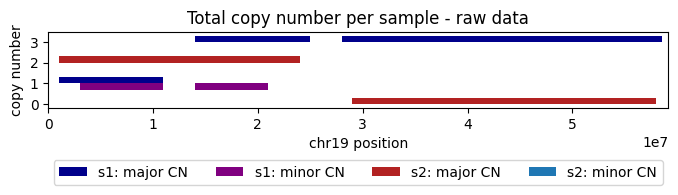

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1), dpi=100)
plot_util(ax)
plot_bars(ax, cns_sid(cns_df, "s1"), "major_cn", "darkblue", .3, .15, "s1: major CN")
plot_bars(ax, cns_sid(cns_df, "s1"), "minor_cn", "purple", .3, -.15, "s1: minor CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "major_cn", "firebrick", .3, .15, "s2: major CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "minor_cn", "goldenrod", .3, -.15, "s2: minor CN")
ax.legend(ncols=4, loc='upper center', bbox_to_anchor=(0.5, -0.6))

In [28]:
cns_fill_df = main_fill(cns_df, add_missing_chromosomes=False)
cns_fill_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,0,1000000,NaN,NaN
1,s1,chr19,1000000,3000000,1.0,NaN
2,s1,chr19,3000000,11000000,1.0,1.0
3,s1,chr19,11000000,14000000,NaN,NaN
4,s1,chr19,14000000,21000000,3.0,1.0
5,s1,chr19,21000000,25000000,3.0,NaN
6,s1,chr19,25000000,28000000,NaN,NaN
7,s1,chr19,28000000,58500000,3.0,NaN
8,s1,chr19,58500000,59128983,NaN,NaN
9,s2,chr19,0,1000000,NaN,NaN


In [33]:
cns_imp_df = main_impute(cns_fill_df)
cns_imp_df

,sample_id,chrom,start,end,major_cn,minor_cn
0,s1,chr19,0,12500000,1,1
1,s1,chr19,12500000,59128983,3,1
2,s2,chr19,0,26500000,2,0
3,s2,chr19,26500000,59128983,0,0


Text(26500000, 2, '  26.5MB  ')

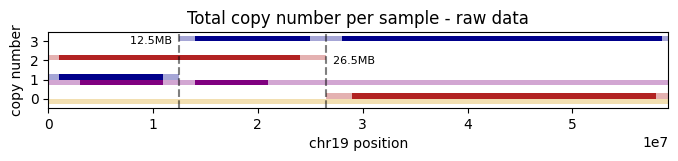

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1), dpi=100)
plot_util(ax)
plot_bars(ax, cns_sid(cns_imp_df, "s1"), "major_cn", "darkblue", .3, .15, "s1: major CN", alpha=.35)
plot_bars(ax, cns_sid(cns_imp_df, "s1"), "minor_cn", "purple", .3, -.15, "s1: minor CN", alpha=.35)
plot_bars(ax, cns_sid(cns_imp_df, "s2"), "major_cn", "firebrick", .3, .15, "s2: major CN", alpha=.35)
plot_bars(ax, cns_sid(cns_imp_df, "s2"), "minor_cn", "goldenrod", .3, -.15, "s2: minor CN", alpha=.35)
plot_bars(ax, cns_sid(cns_df, "s1"), "major_cn", "darkblue", .3, .15, "s1: major CN")
plot_bars(ax, cns_sid(cns_df, "s1"), "minor_cn", "purple", .3, -.15, "s1: minor CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "major_cn", "firebrick", .3, .15, "s2: major CN")
plot_bars(ax, cns_sid(cns_df, "s2"), "minor_cn", "goldenrod", .3, -.15, "s2: minor CN")
ax.axvline(12500000, color='k', linestyle='--', alpha=.5)
ax.text(12500000, 3, '  12.5MB  ', color='k', fontsize=8, ha='right', va='center')
ax.axvline(26500000, color='k', linestyle='--', alpha=.5)
ax.text(26500000, 2, '  26.5MB  ', color='k', fontsize=8, ha='left', va='center')

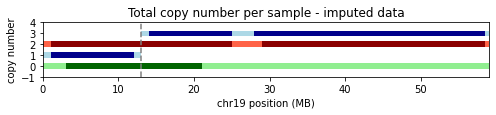

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1))
yticks = np.arange(-1, 5)


ax.barh([1, 3], [13,47], left=[0, 13], height=0.5, color='lightblue', label="sample1")
ax.barh([2], [60], height=0.5, color='tomato', label="sample2")
ax.barh([0], [60], height=0.5, color='lightgreen', label="sample3")

# Add horizontal bars
ax.barh([1, 3, 3], [11, 11, 30.5], left=[1, 14, 28], height=0.5, color='darkblue', label="sample1")
ax.barh([2, 2], [24, 29.5], left=[1, 29], height=0.5, color='darkred', label="sample2")
ax.barh([0], [18], left=[3], height=0.5, color='darkgreen', label="sample3")

plt.axvline(x=13, color='gray', linestyle='--')


# Set the limits of the x-axis
ax.set_xlim(0, x_max)
ax.set_yticks(yticks)

# label
ax.set_title('Total copy number per sample - imputed data')
ax.set_xlabel('chr19 position (MB)')
ax.set_ylabel('copy number')

fig.savefig(f'{docs_path}/example_impute.png', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(f'{docs_path}/example_impute.pdf', transparent=True, bbox_inches='tight')


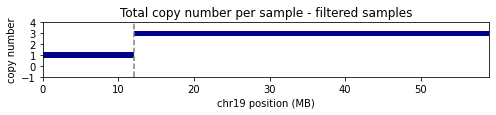

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1))
yticks = np.arange(-1, 5)


# Add horizontal bars
ax.barh([1, 3], [12, 48], left=[0, 12], height=0.5, color='darkblue', label="sample1")

plt.axvline(x=12, color='gray', linestyle='--')


# Set the limits of the x-axis
ax.set_xlim(0, x_max)
ax.set_yticks(yticks)

# label
ax.set_title('Total copy number per sample - filtered samples')
ax.set_xlabel('chr19 position (MB)')
ax.set_ylabel('copy number')

fig.savefig(f'{docs_path}/example_filter.png', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(f'{docs_path}/example_filter.pdf', transparent=True, bbox_inches='tight')


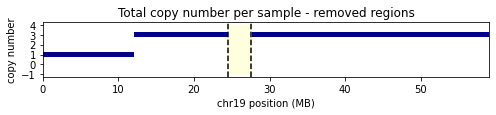

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1))
yticks = np.arange(-1, 5)


# Add horizontal bars
ax.barh([1, 3], [12, 48], left=[0, 12], height=0.5, color='darkblue', label="sample1")

# add a square on -1 < t < 3 and 0 < x < 100
plt.fill_between([24.5, 27.5], -1, 4, color='#FFFFDD', alpha=1)

plt.axvline(x=24.5, color='k', linestyle='--')
plt.axvline(x=27.5, color='k', linestyle='--')


# Set the limits of the x-axis
ax.set_xlim(0, x_max)
ax.set_yticks(yticks)

# label
ax.set_title('Total copy number per sample - removed regions')
ax.set_xlabel('chr19 position (MB)')
ax.set_ylabel('copy number')

fig.savefig(f'{docs_path}/example_remove.png', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(f'{docs_path}/example_remove.pdf', transparent=True, bbox_inches='tight')


In [9]:
l_borders = np.linspace(0, 24.5, 6)
r_borders = np.linspace(27.5, x_max, 7)
print(l_borders)
print(r_borders)

[ 0.   4.9  9.8 14.7 19.6 24.5]
[27.5        32.76666667 38.03333333 43.3        48.56666667 53.83333333
 59.1       ]


In [10]:
r_borders[1] - r_borders[0]

5.266666666666666

2.1020408163265305


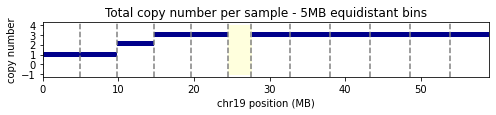

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 1))
yticks = np.arange(-1, 5)

mid_val = ((12-9.8) + (14.7-12)*3) / (14.7-9.8)
print(mid_val)
# Add horizontal bars
ax.barh([1, mid_val, 3], [9.8, (14.7-9.8), 45.3], left=[0, 9.8, 14.7], height=0.5, color='darkblue', label="sample1")

# add a square on -1 < t < 3 and 0 < x < 100
plt.fill_between([24.5, 27.5], -1, 4, color='#FFFFDD', alpha=1)

for bar_pos in np.concatenate([l_borders, r_borders])[:-1]:
	plt.axvline(x=bar_pos, color='gray', linestyle='--')

# Set the limits of the x-axis
ax.set_xlim(0, x_max)
ax.set_yticks(yticks)

# label
ax.set_title('Total copy number per sample - 5MB equidistant bins')
ax.set_xlabel('chr19 position (MB)')
ax.set_ylabel('copy number')

fig.savefig(f'{docs_path}/example_bin.png', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(f'{docs_path}/example_bin.pdf', transparent=True, bbox_inches='tight')


Binned into 552 CNS.                                        


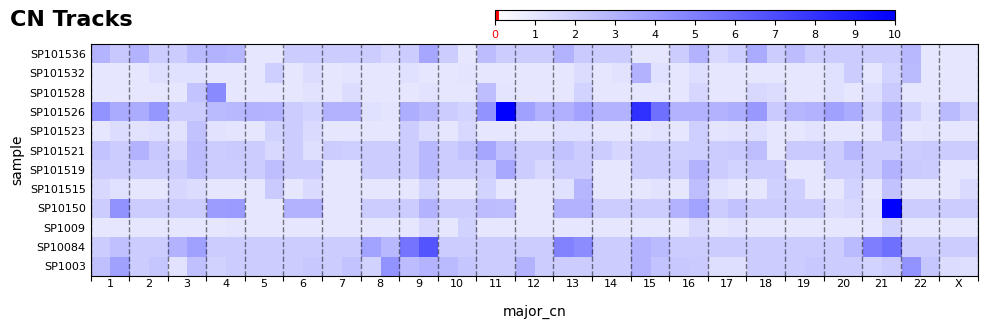

In [12]:
pcawg_cns_df = load_cns_out("PCAWG_cns_imp.tsv")
subset_arms = bin_by_break_type(cns_head(pcawg_cns_df, 12), "arms", hg19)
subset_arms = add_cns_loc(drop_Y(subset_arms))
fig_CN_heatmap(subset_arms, width=10, column="major_cn")
plt.savefig(f'{docs_path}/example_heatmap.png', transparent=True, bbox_inches='tight', dpi=300)
plt.savefig(f'{docs_path}/example_heatmap.pdf', transparent=True, bbox_inches='tight')

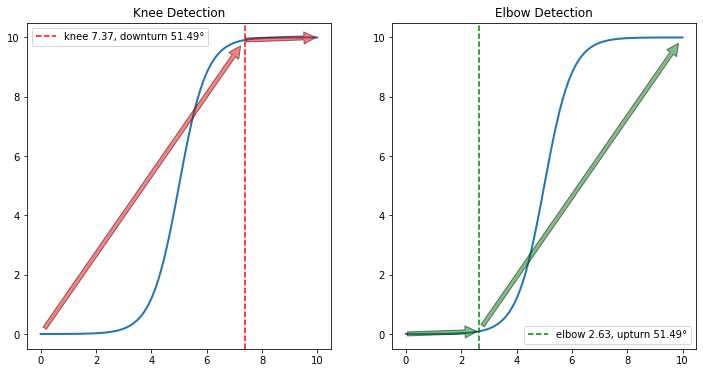

In [13]:
from cns.utils.kneepoint import find_knee
import numpy as np
import matplotlib.pyplot as plt

def logistic(x, L=1, k=1, x0=0):
    return L / (1 + np.exp(-k * (x - x0)))
# Generate points for the x-axis
test_x = np.linspace(0, 10, 100)
# Calculate the corresponding y-values using the logistic function
test_y = logistic(test_x, L=10, k=2, x0=5)

# Find knee and elbow points
knee, knee_val = find_knee(test_x, test_y, True)
elbow, elbow_val = find_knee(test_x,test_y,  False)

# Create a figure with two subplots side by side
configs = [
    {
        'title': "Knee Detection",
        'line_color': 'r',
        'label': f'knee {test_x[knee]:.2f}, downturn {knee_val:.2f}°',
        'point': knee,
        'point_val': knee_val
    },
    {
        'title': "Elbow Detection",
        'line_color': 'g',
        'label': f'elbow {test_x[elbow]:.2f}, upturn {elbow_val:.2f}°',
        'point': elbow,
        'point_val': elbow_val
    }
]

# Plot data and annotations
arrow_alpha = 0.5
arrow_shrink = 0.02
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, plot in enumerate(configs):
    ax = axs[i]
    point = plot['point']
    line_color = plot['line_color']
    label = plot['label']
    
    ax.plot(test_x, test_y, linewidth=2)
    ax.axvline(x=test_x[point], color=line_color, linestyle='--', label=label)
    ax.annotate('', xy=(test_x[point], test_y[point]), xytext=(test_x[0], test_y[0]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.annotate('', xy=(test_x[-1], test_y[-1]), xytext=(test_x[point], test_y[point]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.legend()
    ax.set_title(plot['title'])

fig.savefig(f'{docs_path}/example_knee.png', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(f'{docs_path}/example_knee.pdf', transparent=True, bbox_inches='tight')

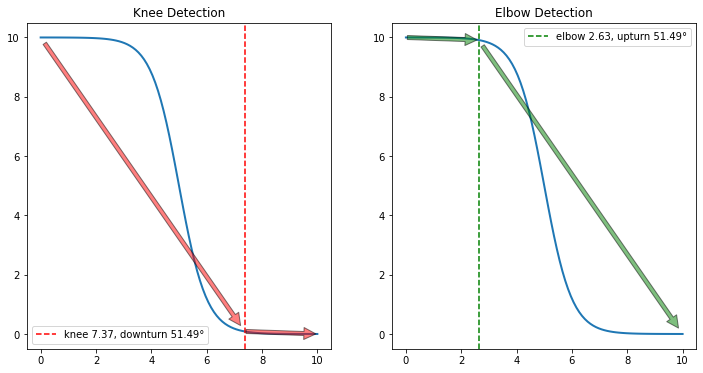

In [14]:
from cns.utils.kneepoint import find_knee
import numpy as np
import matplotlib.pyplot as plt

def logistic(x, L=1, k=1, x0=0):
    return L / (1 + np.exp(-k * (x - x0)))
# Generate points for the x-axis
test_x = np.linspace(0, 10, 100)
# Calculate the corresponding y-values using the logistic function
test_y = 10 - logistic(test_x, L=10, k=2, x0=5)

# Find knee and elbow points
knee, knee_val = find_knee(test_x, test_y, True)
elbow, elbow_val = find_knee(test_x,test_y,  False)

# Create a figure with two subplots side by side
configs = [
    {
        'title': "Knee Detection",
        'line_color': 'r',
        'label': f'knee {test_x[knee]:.2f}, downturn {knee_val:.2f}°',
        'point': knee,
        'point_val': knee_val
    },
    {
        'title': "Elbow Detection",
        'line_color': 'g',
        'label': f'elbow {test_x[elbow]:.2f}, upturn {elbow_val:.2f}°',
        'point': elbow,
        'point_val': elbow_val
    }
]

# Plot data and annotations
arrow_alpha = 0.5
arrow_shrink = 0.02
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, plot in enumerate(configs):
    ax = axs[i]
    point = plot['point']
    line_color = plot['line_color']
    label = plot['label']
    
    ax.plot(test_x, test_y, linewidth=2)
    ax.axvline(x=test_x[point], color=line_color, linestyle='--', label=label)
    ax.annotate('', xy=(test_x[point], test_y[point]), xytext=(test_x[0], test_y[0]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.annotate('', xy=(test_x[-1], test_y[-1]), xytext=(test_x[point], test_y[point]),
                arrowprops=dict(facecolor=line_color, alpha=arrow_alpha, shrink=arrow_shrink))
    ax.legend()
    ax.set_title(plot['title'])

fig.savefig(f'{docs_path}/example_knee_down.png', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(f'{docs_path}/example_knee_down.pdf', transparent=True, bbox_inches='tight')